In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
start = time.time()

import wdatmos
import spec_plot_tools as spt
import cal_params as cp
import plot_spec as ps
print(os.getcwd())



no file_setting specificied


/Users/BenKaiser/Desktop/radial_velocity_calculations


In [2]:
#target_dir= '/Users/BenKaiser/Desktop/files_for_Dufour/' #directory used before 2019-11-15 4:14 PM
target_dir= '/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/'
M0703_file='ravg_fwctb.GaiaJ1644m0449_20190703_400m2.fits'
M0729_file='ravg_fwctb.GaiaJ1644m0449_20190729_400m1.fits'
M0825_file='ravg_fwctb.GaiaJ1644m0449_20190825_400m2.fits'
model_spec_file='J1644_fit_flambda.dms'
#target_spec_file= glob(target_dir+target_spec_file)
#model_spec_file= glob(target_dir+model_spec_file)
print(model_spec_file)

J1644_fit_flambda.dms


In [3]:
os.chdir(target_dir)

In [4]:
print(os.getcwd())

/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper


In [5]:
M0703_spec, M0703_header, M0703_noise= spt.retrieve_spec(M0703_file)
M0729_spec, M0729_header, M0729_noise= spt.retrieve_spec(M0729_file)
M0825_spec, M0825_header, M0825_noise= spt.retrieve_spec(M0825_file)
model_spec= spt.retrieve_model_spec(model_spec_file)

In [6]:
model_spec[1]=model_spec[1]*1e16 #rescaling flux

Ok we now have all of those spectra, so we just need to do the measurements and stuff now

In [7]:
li_bounds= [6650,6770] #approximately even on either side in air...


So, let's run this on each of the target spectra

I have made this into a comparative test of the RMS method in the "generic" version and the propagated uncertainties, and the end result appears to be remarkably similar. Oh I had initially thought the issue was numerical precision, but in reality, it's probably that the generic method uses the differences of central wavelength values to get the bin width instead of provided dlambda values that the file-specific version uses, so that's probably what this was.


=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_noise_single 0.0132714933182 cont_noise_merge 0.00169924059652
abs_noise[1] 0.0119919328988
cont_spec.shape (2, 61)
abs_spec.shape (2, 60)
cont_energy 25.0774660352 +/- 0.0260935193111
abs_energy/abs_energy_noise: 121.573367406
abs_energy 22.6596510205 +/- 0.186386636349
energy_dif 2.41781501476 +/- 0.188204277209


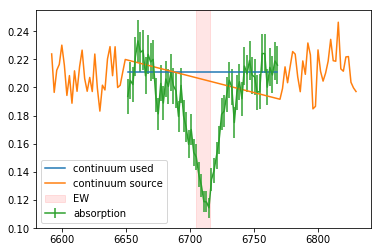

EW: 11.4681356677 +/- 0.89268706294

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_noise_single 0.00989510761598 cont_noise_merge 0.00126693870575
abs_noise[1] 0.00925346011819
cont_spec.shape (2, 61)
abs_spec.shape (2, 61)
cont_energy 23.7172083349 +/- 0.0194362539732
abs_energy/abs_energy_noise: 155.537980726
abs_energy 22.1793449148 +/- 0.142597613852
energy_dif 1.53786342011 +/- 0.143916112526


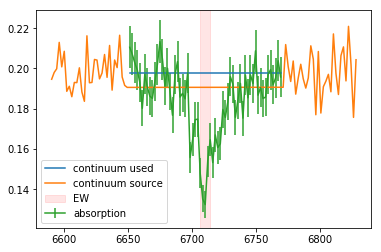

EW: 7.76919541725 +/- 0.727055723731

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_noise_single 0.00993334071629 cont_noise_merge 0.00127183395262
abs_noise[1] 0.00924402927761
cont_spec.shape (2, 61)
abs_spec.shape (2, 60)
cont_energy 25.9797198721 +/- 0.0195289265043
abs_energy/abs_energy_noise: 169.596362345
abs_energy 24.1769033964 +/- 0.142555554035
energy_dif 1.80281647575 +/- 0.143886986752


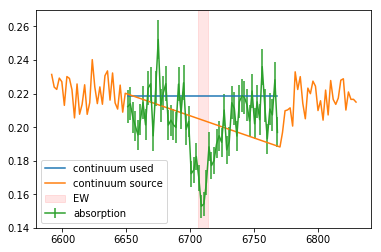

EW: 8.25354704994 +/- 0.658734835746

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_energy 25.0774660352 +/- 0.025077874796
abs_energy/abs_energy_noise: 118.723562111
abs_energy 22.6596510205 +/- 0.19086060608
energy_dif 2.41781501476 +/- 0.192501092873


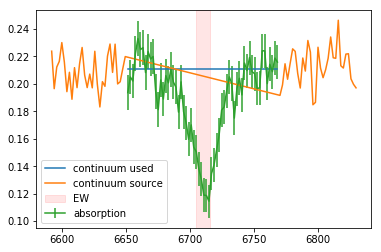

EW: 11.4681356677 +/- 0.9130676399

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_energy 23.7172083349 +/- 0.0183584170039
abs_energy/abs_energy_noise: 161.929124731
abs_energy 22.1793449148 +/- 0.136969460877
energy_dif 1.53786342011 +/- 0.13819430049


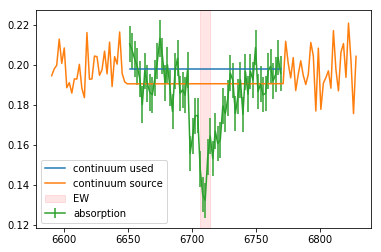

EW: 7.76919541725 +/- 0.698149466342

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_energy 25.9797198721 +/- 0.0234381891988
abs_energy/abs_energy_noise: 137.534734512
abs_energy 24.1769033964 +/- 0.175787618177
energy_dif 1.80281647575 +/- 0.177343270008


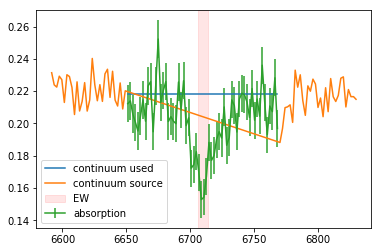

EW: 8.25354704994 +/- 0.811902399768


In [8]:
ew0703= spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms')
ew0729=spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms')
ew0825=spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms')
ew0703= spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=60)
ew0729=spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=60)
ew0825=spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=60)


=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_energy 21.5580809924 +/- 0.0288341501848
abs_energy/abs_energy_noise: 87.1974973284
abs_energy 21.5543845248 +/- 0.247190403224
energy_dif 0.00369646762706 +/- 0.248866437398


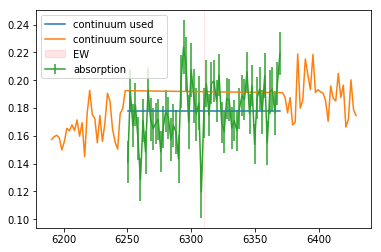

EW: 0.0207650683731 +/- 1.39801808367

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_energy 19.8189538819 +/- 0.0203370932188
abs_energy/abs_energy_noise: 92.5683271451
abs_energy 20.0511074203 +/- 0.216608726102
energy_dif -0.232153538328 +/- 0.217561342118


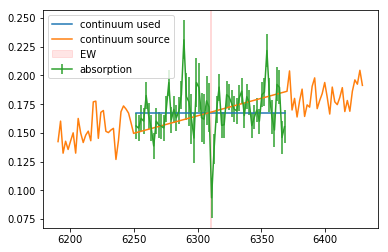

EW: -1.38649339284 +/- 1.29934424242

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_energy 22.3664039596 +/- 0.0274023186648
abs_energy/abs_energy_noise: 82.281870159
abs_energy 22.2753944789 +/- 0.270720566217
energy_dif 0.0910094807512 +/- 0.272103862599


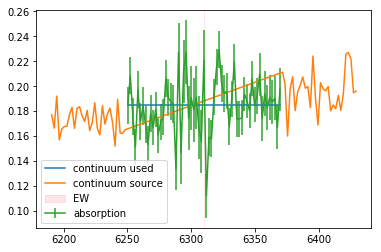

EW: 0.492719000322 +/- 1.47315139101


In [9]:
control_bounds= [6250,6370]
cew0703= spt.get_ew(M0703_file, control_bounds, plot_all=True, cont_width=60)
cew0729=spt.get_ew(M0729_file, control_bounds, plot_all=True, cont_width=60)
cew0825= spt.get_ew(M0825_file, control_bounds, plot_all=True, cont_width=60)

So I've realized that it's also probably pretty important to do the equivalent width measurement on the model spectrum to verify that it's actually the right amount of lithium abundance since the model absorption looks pretty bad to me at least, and given that it wasn't a requirement to have the continuum-ish portion actually be good there, it's possible that the abundance is overestimated.

Probably should be using noise_method='rms' since you didn't provide a noise value
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_energy 22.6110611613 +/- 1.52553539056e-10
abs_energy/abs_energy_noise: 14881879156.3
abs_energy 20.178719647 +/- 1.35592551418e-09
energy_dif 2.43234151434 +/- 1.36448033415e-09


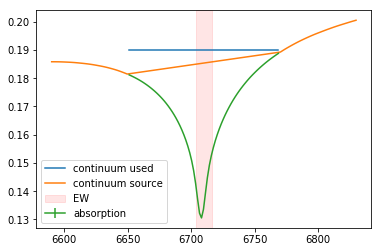

EW: 12.7990451802 +/- 7.17993149453e-09
Probably should be using noise_method='rms' since you didn't provide a noise value
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_energy 19.2747928533 +/- 1.45304002051e-10
abs_energy/abs_energy_noise: 14732901358.9
abs_energy 19.503156396 +/- 1.32378245947e-09
energy_dif -0.228363542747 +/- 1.33173317636e-09


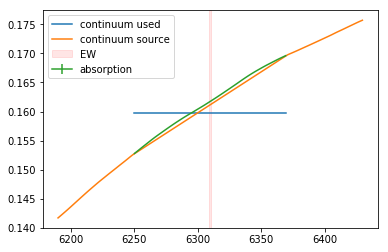

EW: -1.42884250248 +/- 8.3324901228e-09


In [10]:
ew_model= spt.get_generic_ew(model_spec, li_bounds, plot_all=True, cont_width=60)
cew_model= spt.get_generic_ew(model_spec, control_bounds, plot_all=True, cont_width=60)




=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_noise_single 0.0151042677899 cont_noise_merge 0.00158335748939
abs_noise[1] 0.0135901190908
cont_spec.shape (2, 91)
abs_spec.shape (2, 60)
cont_energy 25.1842755335 +/- 0.0243140196335
abs_energy/abs_energy_noise: 107.276445076
abs_energy 22.6596510205 +/- 0.211226714349
energy_dif 2.52462451303 +/- 0.212621486227


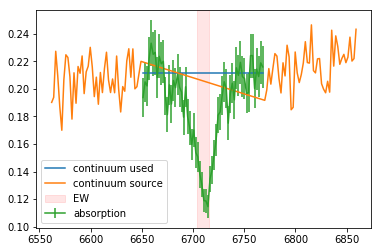

EW: 11.9239661685 +/- 1.00422514135

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_noise_single 0.0111080602361 cont_noise_merge 0.00115809533572
abs_noise[1] 0.0103328711516
cont_spec.shape (2, 92)
abs_spec.shape (2, 61)
cont_energy 23.8431931244 +/- 0.0177664751799
abs_energy/abs_energy_noise: 139.289891493
abs_energy 22.1793449148 +/- 0.159231547078
energy_dif 1.66384820968 +/- 0.160219640573


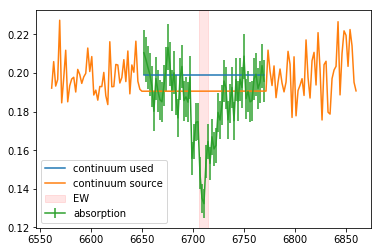

EW: 8.36124856117 +/- 0.805143300585

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_noise_single 0.011860431516 cont_noise_merge 0.00124331105153
abs_noise[1] 0.011067310489
cont_spec.shape (2, 91)
abs_spec.shape (2, 60)
cont_energy 25.9094885537 +/- 0.0190909592381
abs_energy/abs_energy_noise: 141.656253382
abs_energy 24.1769033964 +/- 0.170673039976
energy_dif 1.73258515728 +/- 0.171737448739


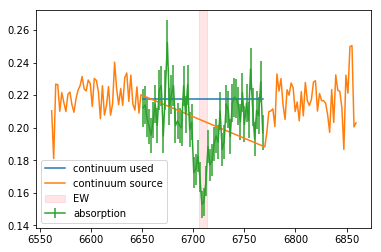

EW: 7.95351906198 +/- 0.788369371895

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_energy 25.1842755335 +/- 0.0210669608536
abs_energy/abs_energy_noise: 118.723562111
abs_energy 22.6596510205 +/- 0.19086060608
energy_dif 2.52462451303 +/- 0.19201975886


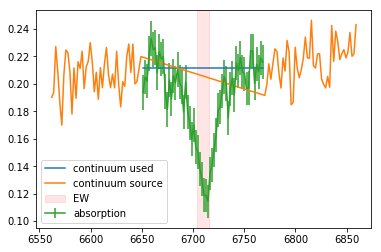

EW: 11.9239661685 +/- 0.906921839866

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_energy 23.8431931244 +/- 0.0156616243057
abs_energy/abs_energy_noise: 161.929124731
abs_energy 22.1793449148 +/- 0.136969460877
energy_dif 1.66384820968 +/- 0.137861958817


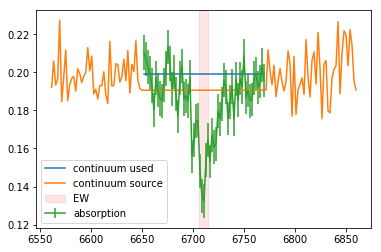

EW: 8.36124856117 +/- 0.692790422887

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_energy 25.9094885537 +/- 0.019991982845
abs_energy/abs_energy_noise: 137.534734512
abs_energy 24.1769033964 +/- 0.175787618177
energy_dif 1.73258515728 +/- 0.176920790419


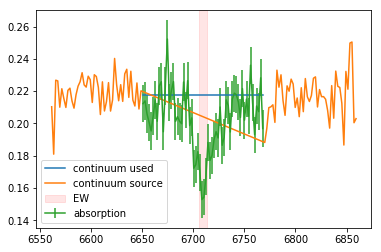

EW: 7.95351906198 +/- 0.812163761846


(7.953519061984279, 0.81216376184621331)

In [11]:
spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=90, noise_method='rms')
spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=90, noise_method='rms')
spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=90,noise_method='rms')
spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=90)
spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=90)
spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=90)

In [12]:
inbounds= np.where((model_spec[0]>3000)& (model_spec[0]<10000))

In [13]:
inmodel=model_spec[:,inbounds]
inmodel=inmodel[:,0,:]

In [14]:
print(inmodel.shape)

(2, 4124)



=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_noise_single 0.0153101655272 cont_noise_merge 0.00197653387048
abs_noise[1] 0.0141231211669
cont_spec.shape (2, 60)
abs_spec.shape (2, 89)
cont_energy 37.6379485115 +/- 0.036965315687
abs_energy/abs_energy_noise: 130.204606936
abs_energy 34.7197272289 +/- 0.26665513645
energy_dif 2.91822128264 +/- 0.269205119489


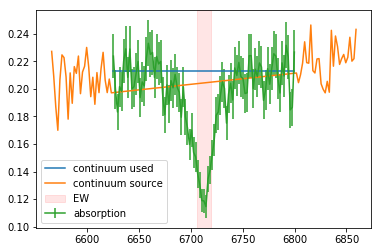

EW: 13.6797269062 +/- 1.26195108584

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_noise_single 0.0121907171542 cont_noise_merge 0.00156086138856
abs_noise[1] 0.0115920191293
cont_spec.shape (2, 61)
abs_spec.shape (2, 89)
cont_energy 34.8208688083 +/- 0.028922924296
abs_energy/abs_energy_noise: 153.555830884
abs_energy 33.1108752275 +/- 0.215627599662
energy_dif 1.70999358071 +/- 0.217558721466


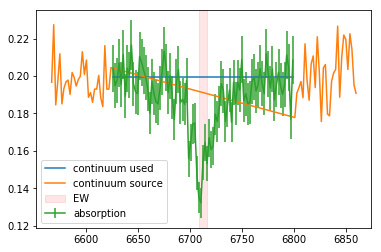

EW: 8.58475047943 +/- 1.09221891794

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_noise_single 0.0114003065182 cont_noise_merge 0.00147177324289
abs_noise[1] 0.0108176175263
cont_spec.shape (2, 60)
abs_spec.shape (2, 89)
cont_energy 38.6287597586 +/- 0.0275233566432
abs_energy/abs_energy_noise: 180.516477676
abs_energy 36.6544147797 +/- 0.203053013507
energy_dif 1.97434497891 +/- 0.204909886182


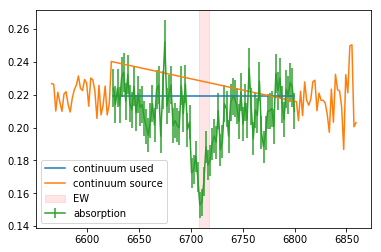

EW: 9.01711820077 +/- 0.935852996284

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_energy 37.6379485115 +/- 0.0321817886515
abs_energy/abs_energy_noise: 149.109889888
abs_energy 34.7197272289 +/- 0.232846575468
energy_dif 2.91822128264 +/- 0.235059982192


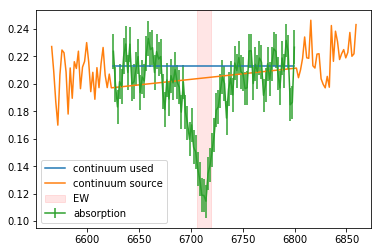

EW: 13.6797269062 +/- 1.10188914805

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_energy 34.8208688083 +/- 0.0239264690662
abs_energy/abs_energy_noise: 199.53944633
abs_energy 33.1108752275 +/- 0.165936489434
energy_dif 1.70999358071 +/- 0.16765260048


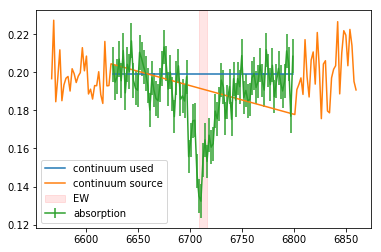

EW: 8.58475047943 +/- 0.841673184381

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_energy 38.6287597586 +/- 0.0308410176158
abs_energy/abs_energy_noise: 170.819696182
abs_energy 36.6544147797 +/- 0.214579557271
energy_dif 1.97434497891 +/- 0.216784581477


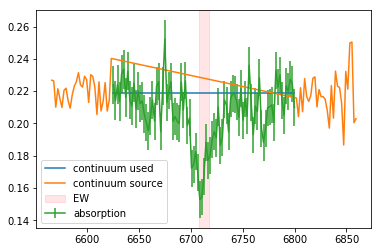

EW: 9.01711820077 +/- 0.990086441916
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.00761485982752 cont_noise_merge 0.000867793815603
abs_noise[1] 0.00693566268076
cont_spec.shape (2, 77)
abs_spec.shape (2, 114)
cont_energy 33.9961804251 +/- 0.0143221712443
abs_energy/abs_energy_noise: 269.469453889
abs_energy 30.969525763 +/- 0.1149277787
energy_dif 3.02665466213 +/- 0.115816747088


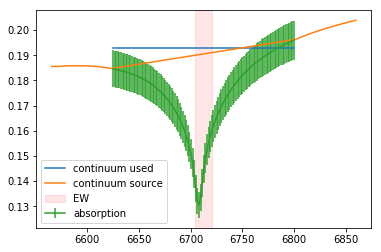

EW: 15.6878452622 +/- 0.600304762159


(15.687845262159749, 0.60030476215853434)

In [15]:
li_bounds= [6625,6800] #approximately even on either side in air...
ew0703= spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms')
ew0729=spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms')
ew0825=spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms')
ew0703= spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=60)
ew0729=spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=60)
ew0825=spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=60)
spt.get_generic_ew(model_spec, li_bounds, plot_all=True, cont_width=60, noise_method='rms')


=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_energy 30.9443878765 +/- 0.0338656190673
abs_energy/abs_energy_noise: 108.027448531
abs_energy 31.3392346091 +/- 0.290104367318
energy_dif -0.394846732537 +/- 0.292074346856


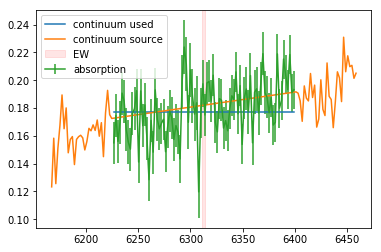

EW: -2.22921196671 +/- 1.64898320165

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_energy 29.5723499302 +/- 0.0236485910124
abs_energy/abs_energy_noise: 120.706758008
abs_energy 29.7807605537 +/- 0.246719910676
energy_dif -0.208410623459 +/- 0.247850701392


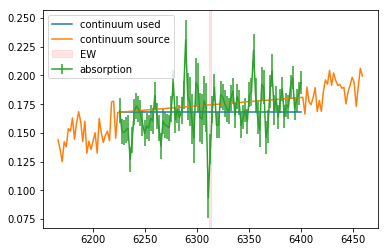

EW: -1.23731910689 +/- 1.4714720555

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_energy 32.4382226465 +/- 0.0315586512604
abs_energy/abs_energy_noise: 104.31276017
abs_energy 32.1417233035 +/- 0.30812839437
energy_dif 0.29649934293 +/- 0.309740303943


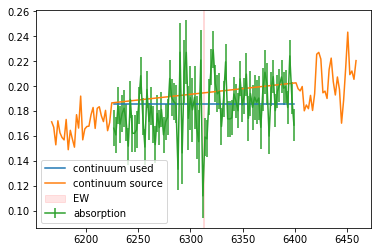

EW: 1.59670245478 +/- 1.6680074187


In [16]:
control_bounds= [6225,6400]
cew0703= spt.get_ew(M0703_file, control_bounds, plot_all=True, cont_width=60)
cew0729=spt.get_ew(M0729_file, control_bounds, plot_all=True, cont_width=60)
cew0825= spt.get_ew(M0825_file, control_bounds, plot_all=True, cont_width=60)

### Using instead the 1-d polynomial for the RMS scatter error bars

li_bounds= [6625,6800] #approximately even on either side in air...
ew0703= spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms', cont_method='poly1')
ew0729=spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms', cont_method='poly1')
ew0825=spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms',cont_method='poly1')
spt.get_generic_ew(model_spec, li_bounds, plot_all=True, cont_width=60, noise_method='rms', cont_method='poly1')
ew0703= spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms_wrong', cont_method='poly1')
ew0729=spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms_wrong', cont_method='poly1')
ew0825=spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms_wrong',cont_method='poly1')
spt.get_generic_ew(model_spec, li_bounds, plot_all=True, cont_width=60, noise_method='rms_wrong', cont_method='poly1')

li_bounds= [6625,6800] #approximately even on either side in air...
#li_bounds= [6225,6400] #control bounds
ew_list=[]
ew_noise_list=[]
width_list=np.arange(20,100,5)
for cont_width in width_list:
    print('Cont_width', cont_width)
    ew0703= spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=cont_width, noise_method='rms', cont_method='poly1')
    ew_list.append(ew0703[0])
    ew_noise_list.append(ew0703[1])
    print('\n\n\n')
plt.figure(figsize=(10,10))
plt.plot(width_list, ew_noise_list,label='noise')
plt.plot(width_list, ew_list,label='EW')
plt.xlabel('Continuum side width (meaning ~number of points in continuum)')
plt.legend(loc='best')
plt.title('2nd order polynomial fit (EW measured on a control region)')
plt.show()

li_bounds= [6625,6800] #approximately even on either side in air...
#li_bounds= [6225,6400] #control bounds
ew_list=[]
ew_noise_list=[]
width_list=np.arange(20,100,5)
for cont_width in width_list:
    print('Cont_width', cont_width)
    ew0703= spt.get_generic_ew(model_spec, li_bounds, plot_all=True, cont_width=cont_width, noise_method='rms', cont_method='poly1')
    ew_list.append(ew0703[0])
    ew_noise_list.append(ew0703[1])
    print('\n\n\n')
plt.figure(figsize=(10,10))
plt.plot(width_list, ew_noise_list,label='noise')
plt.plot(width_list, ew_list,label='EW')
plt.xlabel('Continuum side width (meaning ~number of points in continuum)')
plt.legend(loc='best')
#plt.title('2nd order polynomial fit (EW measured on a control region)')
plt.title('2nd order polynomial fit')
plt.show()


=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_energy 37.6380891138 +/- 0.0321817886515
abs_energy/abs_energy_noise: 149.109889888
abs_energy 34.7197272289 +/- 0.232846575468
energy_dif 2.91836188497 +/- 0.235059982192


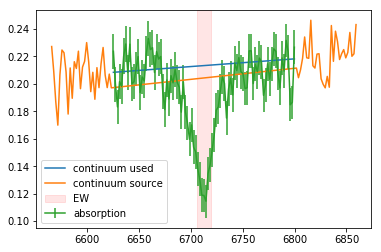

EW: 13.6802936661 +/- 1.10188171045

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_energy 34.814465368 +/- 0.0239264690662
abs_energy/abs_energy_noise: 199.53944633
abs_energy 33.1108752275 +/- 0.165936489434
energy_dif 1.70359014046 +/- 0.16765260048


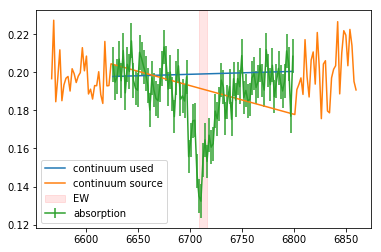

EW: 8.55415755679 +/- 0.841826167721

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_energy 38.6287340684 +/- 0.0308410176158
abs_energy/abs_energy_noise: 170.819696182
abs_energy 36.6544147797 +/- 0.214579557271
energy_dif 1.97431928866 +/- 0.216784581477


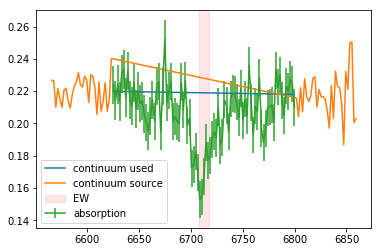

EW: 9.01701170138 +/- 0.990087631257

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_noise_single 0.0140083705094 cont_noise_rms 0.0140083705094
cont_noise_single 0.0140083705094
abs_noise[1] 0.0140083705094
cont_spec.shape (2, 60)
abs_spec.shape (2, 89)
cont_energy 37.6380891138 +/- 0.261985815611
abs_energy/abs_energy_noise: 132.525217626
abs_energy 34.7197272289 +/- 0.261985815611
energy_dif 2.91836188497 +/- 0.370503893586


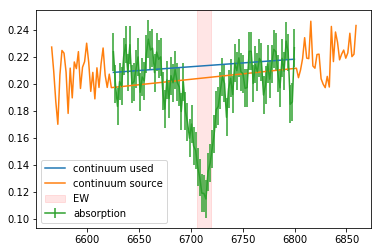

EW: 13.6802936661 +/- 1.73679696641

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_noise_single 0.0122557981299 cont_noise_rms 0.0122557981299
cont_noise_single 0.0122557981299
abs_noise[1] 0.0122557981299
cont_spec.shape (2, 61)
abs_spec.shape (2, 89)
cont_energy 34.814465368 +/- 0.227101217377
abs_energy/abs_energy_noise: 145.797876427
abs_energy 33.1108752275 +/- 0.227101217377
energy_dif 1.70359014046 +/- 0.321169621645


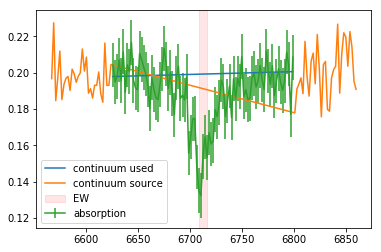

EW: 8.55415755679 +/- 1.61267401164

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_noise_single 0.011523411715 cont_noise_rms 0.011523411715
cont_noise_single 0.011523411715
abs_noise[1] 0.011523411715
cont_spec.shape (2, 60)
abs_spec.shape (2, 89)
cont_energy 38.6287340684 +/- 0.215497171123
abs_energy/abs_energy_noise: 170.092324594
abs_energy 36.6544147797 +/- 0.215497171123
energy_dif 1.97431928866 +/- 0.304759022055


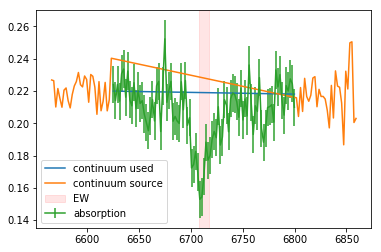

EW: 9.01701170138 +/- 1.39188006912
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.00123509942506 cont_noise_rms 0.00123509942506
cont_noise_single 0.00123509942506
abs_noise[1] 0.00123509942506
cont_spec.shape (2, 77)
abs_spec.shape (2, 114)
cont_energy 34.0122152787 +/- 0.0203842262428
abs_energy/abs_energy_noise: 1519.28875759
abs_energy 30.969525763 +/- 0.0203842262428
energy_dif 3.0426895157 +/- 0.0288276492111


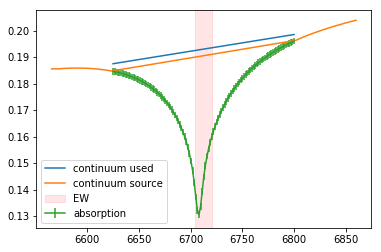

EW: 15.765524616 +/- 0.149368843227


(15.765524616010911, 0.14936884322714608)

In [17]:
li_bounds= [6625,6800] #approximately even on either side in air...
ew0703= spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=60, cont_method='poly1')
ew0729=spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=60, cont_method='poly1')
ew0825=spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=60, cont_method='poly1')
ew0703= spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms', cont_method='poly1')
ew0729=spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms', cont_method='poly1')
ew0825=spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=60, noise_method='rms', cont_method='poly1')
spt.get_generic_ew(model_spec, li_bounds, plot_all=True, cont_width=60, noise_method='rms', cont_method='poly1')


=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_energy 37.4340175668 +/- 0.0529704488918
abs_energy/abs_energy_noise: 149.109889888
abs_energy 34.7197272289 +/- 0.232846575468
energy_dif 2.71429033791 +/- 0.238795720571


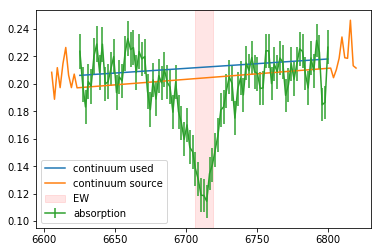

EW: 12.7930296766 +/- 1.12549519748

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_energy 34.2428637851 +/- 0.0381071974855
abs_energy/abs_energy_noise: 199.53944633
abs_energy 33.1108752275 +/- 0.165936489434
energy_dif 1.13198855751 +/- 0.170255916273


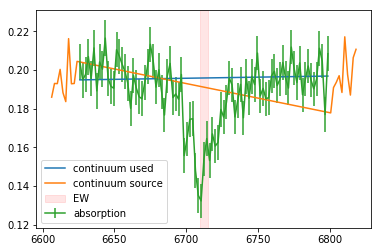

EW: 5.77888499409 +/- 0.869168997491

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_energy 38.5745003267 +/- 0.0492791227177
abs_energy/abs_energy_noise: 170.819696182
abs_energy 36.6544147797 +/- 0.214579557271
energy_dif 1.92008554695 +/- 0.220165434013


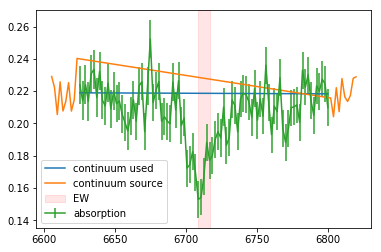

EW: 8.78164413993 +/- 1.00694185032

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_noise_single 0.0116586566208 cont_noise_rms 0.0116586566208
cont_noise_single 0.0116586566208
abs_noise[1] 0.0116586566208
cont_spec.shape (2, 20)
abs_spec.shape (2, 89)
cont_energy 37.4340175668 +/- 0.218041253383
abs_energy/abs_energy_noise: 159.234670918
abs_energy 34.7197272289 +/- 0.218041253383
energy_dif 2.71429033791 +/- 0.308356897691


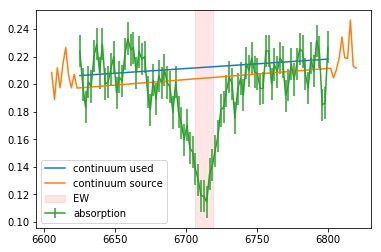

EW: 12.7930296766 +/- 1.45335187177

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_noise_single 0.0107957858047 cont_noise_rms 0.0107957858047
cont_noise_single 0.0107957858047
abs_noise[1] 0.0107957858047
cont_spec.shape (2, 20)
abs_spec.shape (2, 89)
cont_energy 34.2428637851 +/- 0.20004703674
abs_energy/abs_energy_noise: 165.515449602
abs_energy 33.1108752275 +/- 0.20004703674
energy_dif 1.13198855751 +/- 0.28290923247


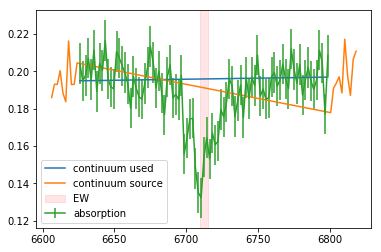

EW: 5.77888499409 +/- 1.44427247728

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_noise_single 0.00999713349302 cont_noise_rms 0.00999713349302
cont_noise_single 0.00999713349302
abs_noise[1] 0.00999713349302
cont_spec.shape (2, 20)
abs_spec.shape (2, 89)
cont_energy 38.5745003267 +/- 0.186954527042
abs_energy/abs_energy_noise: 196.06058949
abs_energy 36.6544147797 +/- 0.186954527042
energy_dif 1.92008554695 +/- 0.26439362769


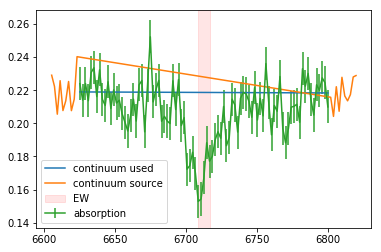

EW: 8.78164413993 +/- 1.20922255518
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.000612678765772 cont_noise_rms 0.000612678765772
cont_noise_single 0.000612678765772
abs_noise[1] 0.000612678765772
cont_spec.shape (2, 25)
abs_spec.shape (2, 114)
cont_energy 33.7474439637 +/- 0.010111722443
abs_energy/abs_energy_noise: 3062.73495318
abs_energy 30.969525763 +/- 0.010111722443
energy_dif 2.77791820073 +/- 0.0143001350178


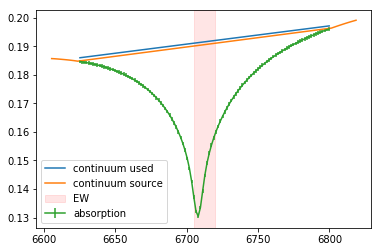

EW: 14.5065885914 +/- 0.0746768480984


(14.506588591410615, 0.074676848098369594)

In [56]:
li_bounds= [6625,6800] #approximately even on either side in air...
cont_width=20.
ew0703= spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=cont_width, cont_method='poly1')
ew0729=spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=cont_width, cont_method='poly1')
ew0825=spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=cont_width, cont_method='poly1')
ew0703= spt.get_ew(M0703_file, li_bounds, plot_all=True, cont_width=cont_width, noise_method='rms', cont_method='poly1')
ew0729=spt.get_ew(M0729_file, li_bounds, plot_all=True, cont_width=cont_width, noise_method='rms', cont_method='poly1')
ew0825=spt.get_ew(M0825_file, li_bounds, plot_all=True, cont_width=cont_width, noise_method='rms', cont_method='poly1')
spt.get_generic_ew(model_spec, li_bounds, plot_all=True, cont_width=cont_width, noise_method='rms', cont_method='poly1')


=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0158206585776
cont_energy 30.9446169915 +/- 0.0338656190673
abs_energy/abs_energy_noise: 108.027448531
abs_energy 31.3392346091 +/- 0.290104367318
energy_dif -0.394617617555 +/- 0.292074346856


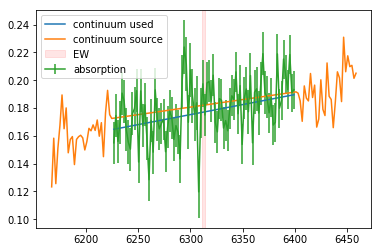

EW: -2.22788881569 +/- 1.64896127736

=====

(2, 1691)
np.nanmean(noise_spec[1]) 8.17915762159
cont_energy 29.5732919366 +/- 0.0236485910124
abs_energy/abs_energy_noise: 120.706758008
abs_energy 29.7807605537 +/- 0.246719910676
energy_dif -0.207468617068 +/- 0.247850701392


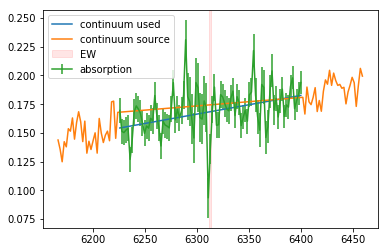

EW: -1.23165554744 +/- 1.47138731448

=====

(2, 2045)
np.nanmean(noise_spec[1]) 0.0153122157015
cont_energy 32.4384584131 +/- 0.0315586512604
abs_energy/abs_energy_noise: 104.31276017
abs_energy 32.1417233035 +/- 0.30812839437
energy_dif 0.296735109553 +/- 0.309740303943


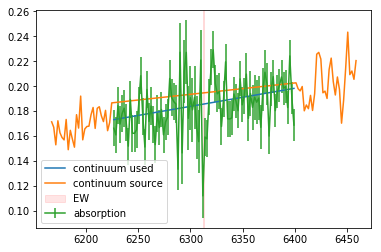

EW: 1.59795126309 +/- 1.66798566796
Probably should be using noise_method='rms' since you didn't provide a noise value
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_energy 27.7615770701 +/- 1.74786237775e-10
abs_energy/abs_energy_noise: 17716912583.9
abs_energy 28.212029087 +/- 1.5923784098e-09
energy_dif -0.450452016945 +/- 1.60194233008e-09


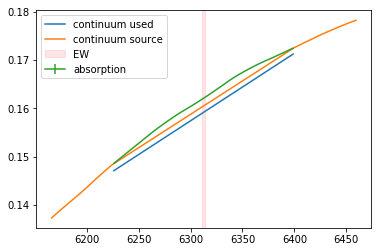

EW: -2.83125967678 +/- 1.00688076711e-08


In [18]:
control_bounds= [6225,6400]
cew0703= spt.get_ew(M0703_file, control_bounds, plot_all=True, cont_width=60, cont_method='poly1')
cew0729=spt.get_ew(M0729_file, control_bounds, plot_all=True, cont_width=60, cont_method='poly1')
cew0825= spt.get_ew(M0825_file, control_bounds, plot_all=True, cont_width=60, cont_method='poly1')
cew_model= spt.get_generic_ew(model_spec, control_bounds, plot_all=True, cont_width=60, cont_method='poly1')

### Actually back into the average method of continuum fitting

Probably should be using noise_method='rms' since you didn't provide a noise value
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_energy 33.9961804251 +/- 1.88081876341e-10
abs_energy/abs_energy_noise: 18764726710.0
abs_energy 30.969525763 +/- 1.6504117668e-09
energy_dif 3.02665466213 +/- 1.66109415513e-09


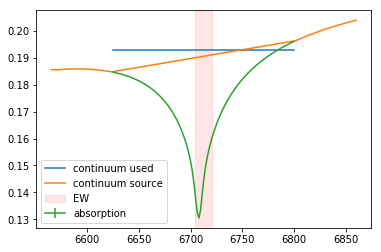

EW: 15.6878452622 +/- 8.6098319698e-09
Probably should be using noise_method='rms' since you didn't provide a noise value
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_energy 27.7306687215 +/- 1.74786237775e-10
abs_energy/abs_energy_noise: 17716912583.9
abs_energy 28.212029087 +/- 1.5923784098e-09
energy_dif -0.481360365506 +/- 1.60194233008e-09


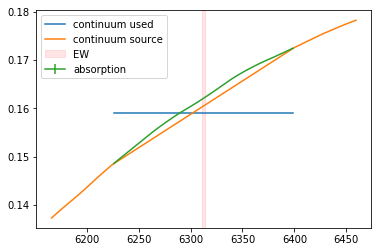

EW: -3.02782775989 +/- 1.00764537431e-08


In [19]:
ew_model= spt.get_generic_ew(model_spec, li_bounds, plot_all=True, cont_width=60)
cew_model= spt.get_generic_ew(model_spec, control_bounds, plot_all=True, cont_width=60)

In [20]:
n=10000
def generate_dist(ew_vals, n=n):
    dist= np.random.normal(loc=ew_vals[0], scale=ew_vals[1], size=n)
    return dist

In [21]:
dist0703= generate_dist(ew0703)
dist0729= generate_dist(ew0729)
dist0825= generate_dist(ew0825)

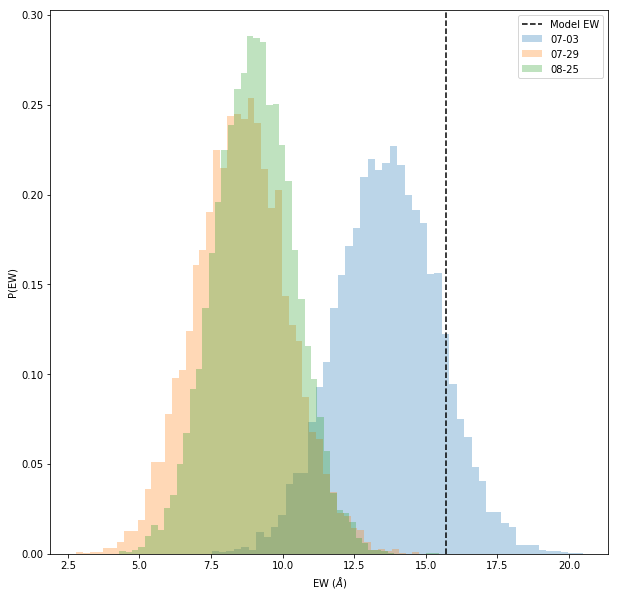

In [22]:
plt.figure(figsize=(10,10))
nbins= 50
plt.hist(dist0703, alpha=0.3, label='07-03', bins=nbins, normed=True)
plt.hist(dist0729, alpha=0.3, label='07-29', bins=nbins, normed=True)
plt.hist(dist0825, alpha= 0.3, label='08-25', bins=nbins, normed=True)
plt.axvline(x=ew_model[0], color='k', linestyle='--', label='Model EW')
plt.legend()
plt.xlabel(r'EW ($\AA$)')
plt.ylabel('P(EW)')
plt.show()

And let's see what the average equivalent width we end up with out of there ends up being...

In [23]:
avg_ew= np.mean([ew0703[0], ew0729[0], ew0825[0]])
errs= np.array([ew0703[1], ew0729[1], ew0825[1]])
avg_ew_err= np.sqrt(np.sum(errs**2)/errs.shape[0]**2)
print(avg_ew,'+/-', avg_ew_err)
avg_ew_all= [avg_ew, avg_ew_err]

10.4171543081 +/- 0.916182374929


In [24]:
distavg= generate_dist(avg_ew_all)

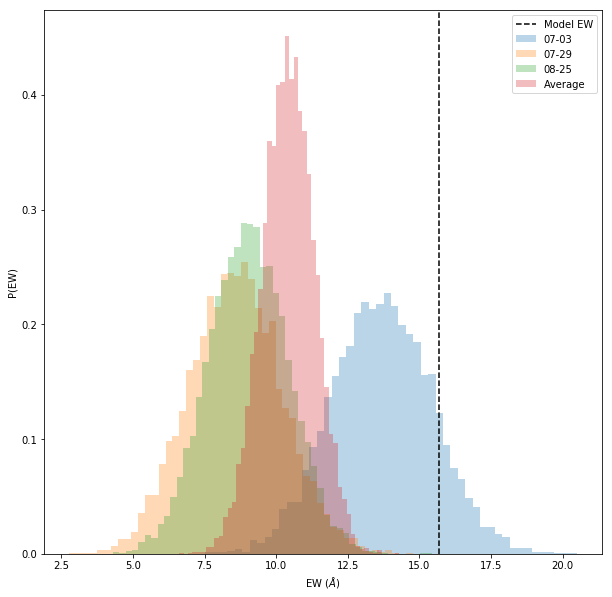

In [25]:
plt.figure(figsize=(10,10))
nbins= 50
plt.hist(dist0703, alpha=0.3, label='07-03', bins=nbins, normed=True)
plt.hist(dist0729, alpha=0.3, label='07-29', bins=nbins, normed=True)
plt.hist(dist0825, alpha= 0.3, label='08-25', bins=nbins, normed=True)
plt.hist(distavg, alpha= 0.3, label='Average', bins=nbins, normed=True)
plt.axvline(x=ew_model[0], color='k', linestyle='--', label='Model EW')
plt.legend()
plt.xlabel(r'EW ($\AA$)')
plt.ylabel('P(EW)')
plt.show()

# Now to do this process for SDSSJ1330+6435 since Simon has sent me those spectra now to evaluate as well.

In [26]:
#j1330_obs_file='J1330_obs_flambda.dms' #this is the one Simon sent me, but I think I'm going to use the SDSS FITS file that I already have
j1330_obs_file='SDSSJ1330p6435coolDZNa_spec.fits'
model1330_file='J1330_fit_flambda.dms'

In [27]:
j1330_obs, j1330_header, j1330_noise= spt.retrieve_sdss_spec(j1330_obs_file)
model1330= spt.retrieve_model_spec(model1330_file)

wavelengths.min:  3804.52
new_wavelengths.min(): 3803.44228561
"Key 'PropErr' does not exist."
trying "ivar"


In [28]:
model1330[1]=model1330[1]*1e16

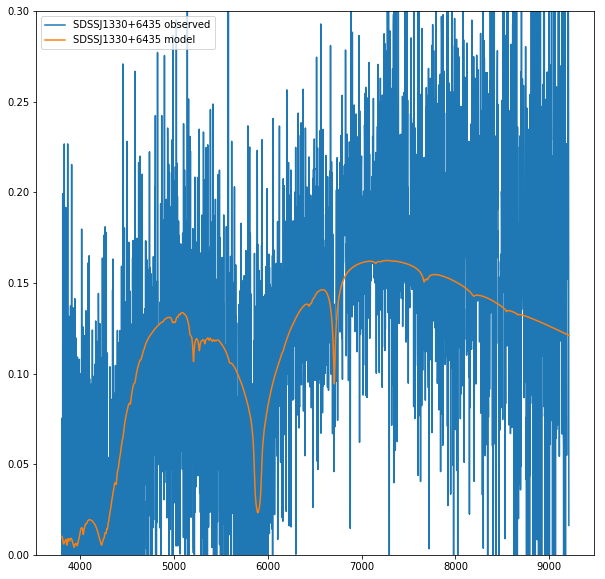

In [29]:
plt.figure(figsize=(10,10))
plt.plot(j1330_obs[0], j1330_obs[1], label='SDSSJ1330+6435 observed')
plt.plot(model1330[0], model1330[1], label='SDSSJ1330+6435 model')
plt.legend()
plt.ylim(0,0.3)
plt.show()

Anyway, now that I have my stuff on vaguely commensurate unit scales (which actually shouldn't be necessary for these calculations, but whatever, I can calculate the equivalent widths, but the SDSS spectrum doesn't appear to have correctly brought in its reported uncertainties, which seems to be a function of the fact that I can't locate which of the million table extensions actually indicates the damn uncertainty values

np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.000946733027458 cont_noise_rms 0.000946733027458
cont_noise_single 0.000946733027458
abs_noise[1] 0.000946733027458
cont_spec.shape (2, 77)
abs_spec.shape (2, 114)
cont_energy 26.4470433497 +/- 0.015625297997
abs_energy/abs_energy_noise: 1511.81481161
abs_energy 23.6225569477 +/- 0.015625297997
energy_dif 2.82448640202 +/- 0.0220975083435


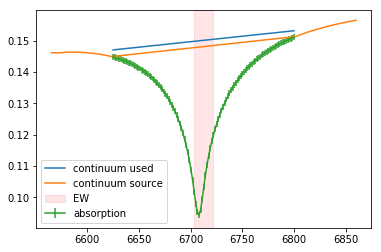

EW: 18.8209639744 +/- 0.147246737729
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.041713741325 cont_noise_rms 0.041713741325
cont_noise_single 0.041713741325
abs_noise[1] 0.041713741325
cont_spec.shape (2, 78)
abs_spec.shape (2, 113)
cont_energy 28.8724189417 +/- 0.685479645631
abs_energy/abs_energy_noise: 39.080927437
abs_energy 26.7891802904 +/- 0.685479645631
energy_dif 2.08323865125 +/- 0.969414611582


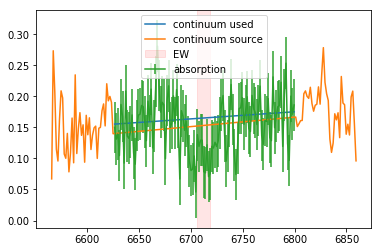

EW: 12.6070029485 +/- 5.86654479514
(2, 3841)
np.nanmean(noise_spec[1]) 0.672087149015
No dlams provided as a kwarg, so we'll make them up.
cont_energy 28.8724189417 +/- 0.776574547651
abs_energy/abs_energy_noise: 4.50096608551
abs_energy 26.7891802904 +/- 5.95187339373
energy_dif 2.08323865125 +/- 6.00232162776


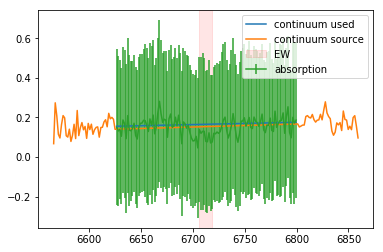

EW: 12.6070029485 +/- 36.3238683257


In [30]:
li_bounds= [6625,6800]
ew_m1330=spt.get_generic_ew(model1330, li_bounds, plot_all=True, cont_width=60, noise_method='rms', cont_method='poly1')
ew_obs1330_rms=spt.get_generic_ew(j1330_obs, li_bounds, plot_all=True, cont_width=60, noise_method='rms', cont_method='poly1')
ew_obs1330=spt.get_generic_ew(j1330_obs, li_bounds, noise= j1330_noise, plot_all=True, cont_width=60, noise_method='prop', cont_method='poly1')

np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0014071144585 cont_noise_rms 0.0014071144585
cont_noise_single 0.0014071144585
abs_noise[1] 0.0014071144585
cont_spec.shape (2, 83)
abs_spec.shape (2, 120)
cont_energy 22.3254211553 +/- 0.0224061215446
abs_energy/abs_energy_noise: 1023.49291928
abs_energy 22.9325067493 +/- 0.0224061215446
energy_dif -0.607085593962 +/- 0.0316870409685


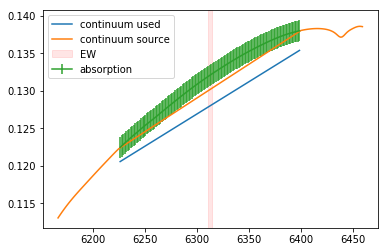

EW: -4.74439612604 +/- 0.247635384387
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0395952358628 cont_noise_rms 0.0395952358628
cont_noise_single 0.0395952358628
abs_noise[1] 0.0395952358628
cont_spec.shape (2, 82)
abs_spec.shape (2, 121)
cont_energy 26.0895619978 +/- 0.633158577439
abs_energy/abs_energy_noise: 40.7072143869
abs_energy 25.7741219527 +/- 0.633158577439
energy_dif 0.315440045108 +/- 0.895421447348


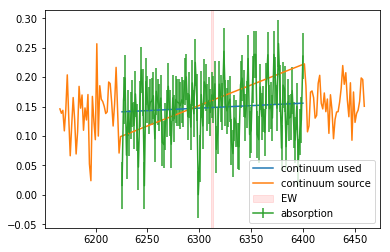

EW: 2.12715361326 +/- 6.03822817251


In [31]:
control_bounds= [6225,6400]
ew_m1330=spt.get_generic_ew(model1330, control_bounds, plot_all=True, cont_width=60, noise_method='rms', cont_method='poly1')
ew_obs1330=spt.get_generic_ew(j1330_obs, control_bounds, plot_all=True, cont_width=60, noise_method='rms', cont_method='poly1')

Probably should be using noise_method='rms' since you didn't provide a noise value
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_energy 26.4381624481 +/- 1.88085544229e-10
abs_energy/abs_energy_noise: 14312850135.5
abs_energy 23.6225569477 +/- 1.6504439524e-09
energy_dif 2.81560550043 +/- 1.66112654905e-09


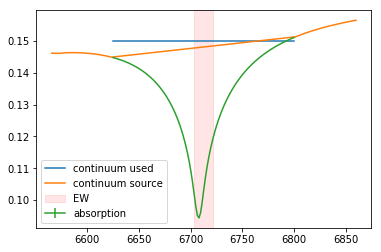

EW: 18.7663990879 +/- 1.10716376105e-08
Probably should be using noise_method='rms' since you didn't provide a noise value
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_energy 28.8063090638 +/- 1.86066470057e-10
abs_energy/abs_energy_noise: 16302116978.5
abs_energy 26.7891802904 +/- 1.64329456878e-09
energy_dif 2.01712877333 +/- 1.65379496041e-09


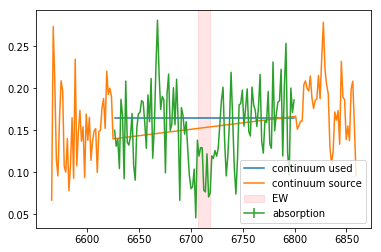

EW: 12.2317367223 +/- 1.00285042858e-08


In [32]:
li_bounds= [6625,6800]
ew_m1330=spt.get_generic_ew(model1330, li_bounds, plot_all=True, cont_width=60)
ew_obs1330=spt.get_generic_ew(j1330_obs, li_bounds, plot_all=True, cont_width=60)

np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.00427542616129 cont_noise_merge 0.000487230029951
abs_noise[1] 0.00381952225754
cont_spec.shape (2, 77)
abs_spec.shape (2, 114)
cont_energy 26.4381624481 +/- 0.00804145856358
abs_energy/abs_energy_noise: 372.545202
abs_energy 23.6225569477 +/- 0.0634085657818
energy_dif 2.81560550043 +/- 0.0639164397502


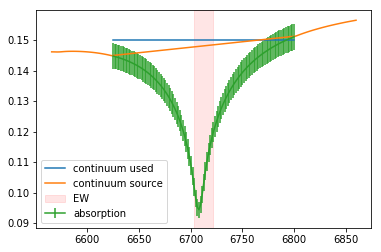

EW: 18.7663990879 +/- 0.426011888543
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0433654273585 cont_noise_merge 0.00491016774739
abs_noise[1] 0.040320824742
cont_spec.shape (2, 78)
abs_spec.shape (2, 113)
cont_energy 28.8063090638 +/- 0.0806885199111
abs_energy/abs_energy_noise: 38.8750472615
abs_energy 26.7891802904 +/- 0.689109909249
energy_dif 2.01712877333 +/- 0.693817774542


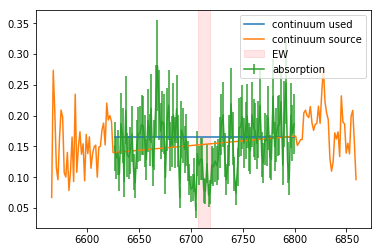

EW: 12.2317367223 +/- 4.20726552696
(2, 3841)
np.nanmean(noise_spec[1]) 0.672087149015
No dlams provided as a kwarg, so we'll make them up.
cont_energy 28.8063090638 +/- 0.776574547651
abs_energy/abs_energy_noise: 4.50096608551
abs_energy 26.7891802904 +/- 5.95187339373
energy_dif 2.01712877333 +/- 6.00232162776


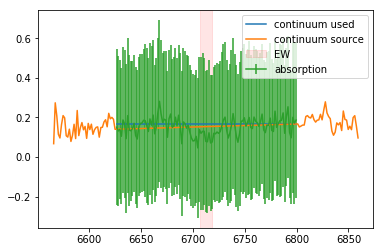

EW: 12.2317367223 +/- 36.3976850879


In [33]:
li_bounds= [6625,6800]
ew_m1330=spt.get_generic_ew(model1330, li_bounds, plot_all=True, cont_width=60, noise_method='rms')
ew_obs1330_rms=spt.get_generic_ew(j1330_obs, li_bounds, plot_all=True, cont_width=60, noise_method='rms')
ew_obs1330=spt.get_generic_ew(j1330_obs, li_bounds, noise= j1330_noise, plot_all=True, cont_width=60, noise_method='prop')

np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0102699434415 cont_noise_merge 0.00112727274199
abs_noise[1] 0.0105551881607
cont_spec.shape (2, 83)
abs_spec.shape (2, 120)
cont_energy 22.3064970723 +/- 0.0179500750052
abs_energy/abs_energy_noise: 136.279779442
abs_energy 22.9325067493 +/- 0.168275197122
energy_dif -0.626009676981 +/- 0.169229864856


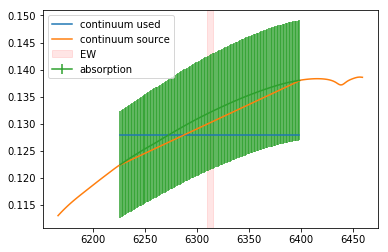

EW: -4.89512044732 +/- 1.32330314085
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0403731935844 cont_noise_merge 0.00445847338004
abs_noise[1] 0.0399417417966
cont_spec.shape (2, 82)
abs_spec.shape (2, 121)
cont_energy 26.0437599529 +/- 0.0712944525104
abs_energy/abs_energy_noise: 38.2892785902
abs_energy 25.7741219527 +/- 0.673142010028
energy_dif 0.269638000145 +/- 0.676906983731


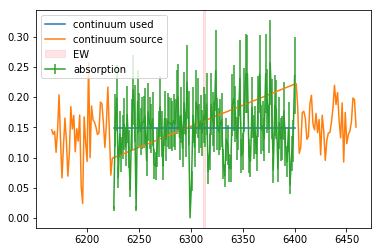

EW: 1.82106420744 +/- 4.57165191542


In [34]:
control_bounds= [6225,6400]
ew_m1330=spt.get_generic_ew(model1330, control_bounds, plot_all=True, cont_width=60, noise_method='rms')
ew_obs1330=spt.get_generic_ew(j1330_obs, control_bounds, plot_all=True, cont_width=60, noise_method='rms')

Probably should be using noise_method='rms' since you didn't provide a noise value
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_energy 26.5187913636 +/- 1.53239873941e-10
abs_energy/abs_energy_noise: 14312850135.5
abs_energy 23.6225569477 +/- 1.6504439524e-09
energy_dif 2.89623441584 +/- 1.65754266882e-09


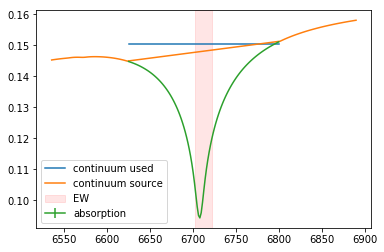

EW: 19.2451097924 +/- 1.10141604811e-08
Probably should be using noise_method='rms' since you didn't provide a noise value
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_energy 28.736196846 +/- 1.51922636627e-10
abs_energy/abs_energy_noise: 16302116978.5
abs_energy 26.7891802904 +/- 1.64329456878e-09
energy_dif 1.94701655561 +/- 1.65030225332e-09


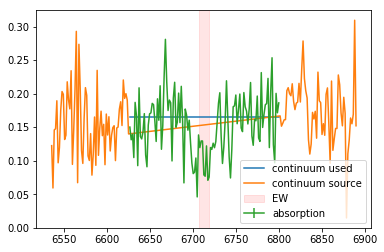

EW: 11.8353871993 +/- 1.00317411825e-08


In [35]:
li_bounds= [6625,6800]
ew_m1330=spt.get_generic_ew(model1330, li_bounds, plot_all=True, cont_width=90)
ew_obs1330=spt.get_generic_ew(j1330_obs, li_bounds, plot_all=True, cont_width=90)

np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.00427542616129 cont_noise_merge 0.000487230029951
abs_noise[1] 0.00381952225754
cont_spec.shape (2, 77)
abs_spec.shape (2, 114)
cont_energy 26.4381624481 +/- 0.00804145856358
abs_energy/abs_energy_noise: 372.545202
abs_energy 23.6225569477 +/- 0.0634085657818
energy_dif 2.81560550043 +/- 0.0639164397502


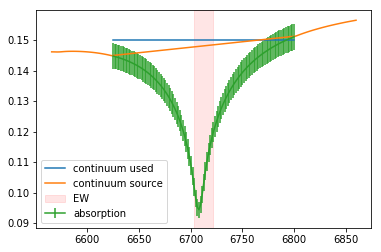

EW: 18.7663990879 +/- 0.426011888543
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0433654273585 cont_noise_merge 0.00491016774739
abs_noise[1] 0.040320824742
cont_spec.shape (2, 78)
abs_spec.shape (2, 113)
cont_energy 28.8063090638 +/- 0.0806885199111
abs_energy/abs_energy_noise: 38.8750472615
abs_energy 26.7891802904 +/- 0.689109909249
energy_dif 2.01712877333 +/- 0.693817774542


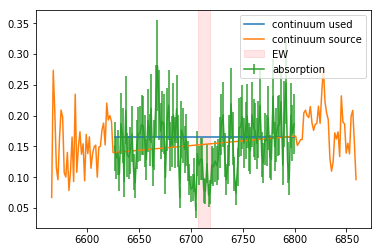

EW: 12.2317367223 +/- 4.20726552696


In [36]:
li_bounds= [6625,6800]
ew_m1330=spt.get_generic_ew(model1330, li_bounds, plot_all=True, cont_width=60, noise_method='rms')
ew_obs1330=spt.get_generic_ew(j1330_obs, li_bounds, plot_all=True, cont_width=60, noise_method='rms')

np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0119726155791 cont_noise_merge 0.00107517261857
abs_noise[1] 0.012386350628
cont_spec.shape (2, 124)
abs_spec.shape (2, 120)
cont_energy 22.160266146 +/- 0.0171204611164
abs_energy/abs_energy_noise: 116.13256864
abs_energy 22.9325067493 +/- 0.197468350333
energy_dif -0.772240603274 +/- 0.1982091309


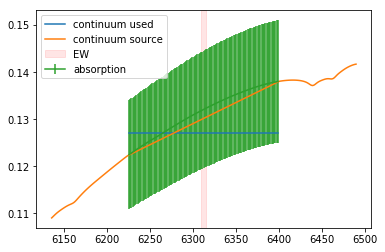

EW: -6.07842933021 +/- 1.5601357785
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0456086803315 cont_noise_merge 0.00411239621322
abs_noise[1] 0.0474201683833
cont_spec.shape (2, 123)
abs_spec.shape (2, 121)
cont_energy 24.7811806699 +/- 0.0657604097941
abs_energy/abs_energy_noise: 32.2508445492
abs_energy 25.7741219527 +/- 0.799176651432
energy_dif -0.992941282826 +/- 0.801877641346


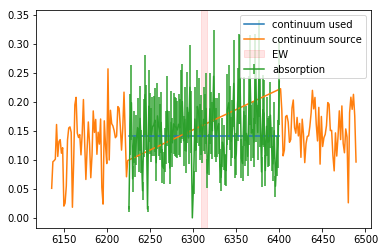

EW: -7.0477326049 +/- 5.69159455428


In [37]:
control_bounds= [6225,6400]
ew_m1330=spt.get_generic_ew(model1330, control_bounds, plot_all=True, cont_width=90, noise_method='rms')
ew_obs1330=spt.get_generic_ew(j1330_obs, control_bounds, plot_all=True, cont_width=90, noise_method='rms')

So those are crap. Now, technically speaking, rebinning the SDSS spectrum after-the-fact shouldn't actually do anything to fix the problem with the SNR, right?

In [38]:
m0729_hdu=fits.open(M0729_file)
m0729_dlambda= np.copy(m0729_hdu[4].data)
m0729_waves= np.copy(m0729_hdu[0].data)
j1330_obs_dlambda_alt= np.copy(j1330_obs[0][1:]-j1330_obs[0][:-1])
j1330_obs_dlambda_alt=np.append(j1330_obs_dlambda_alt, j1330_obs_dlambda_alt[-1])

In [39]:
j1330_hdu= fits.open(j1330_obs_file)
j1330_obs_dlambda= np.copy(j1330_hdu[1].data['wdisp'])

In [40]:
rebin_j1330_obs= spt.rebin_generic_spec(j1330_obs, j1330_obs_dlambda, m0729_waves, m0729_dlambda)

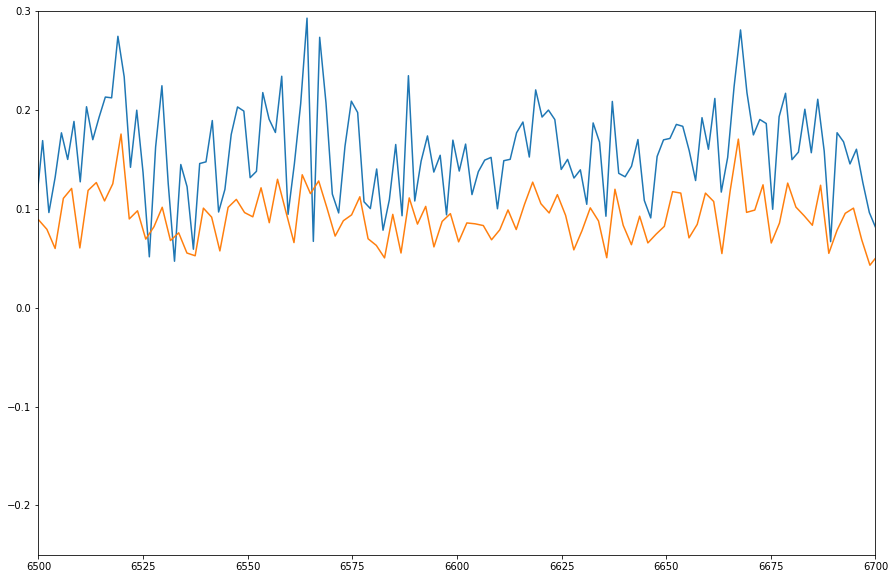

In [41]:
plt.figure(figsize=(15,10))
plt.plot(j1330_obs[0], j1330_obs[1], label='original')
plt.plot(rebin_j1330_obs[0], rebin_j1330_obs[1], label='rebin')
plt.ylim(-0.25, 0.3)
#plt.xlim(3700, 7400)
plt.xlim(6500, 6700)

plt.show()

Ok. So this is concerning for a couple reasons, but the most troubling aspect of this is that the result does not appear to be a spectrum that's actually flux-conservative, which is VERY troubling because it might mean my "flux-conservative" binning actually isn't flux-conservative...

np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0223786971504 cont_noise_merge 0.00286529856011
abs_noise[1] 0.0207660821594
cont_spec.shape (2, 61)
abs_spec.shape (2, 89)
cont_energy 16.1755969039 +/- 0.0530937067859
abs_energy/abs_energy_noise: 37.2199500514
abs_energy 15.0098677179 +/- 0.40327479476
energy_dif 1.16572918598 +/- 0.406754842367


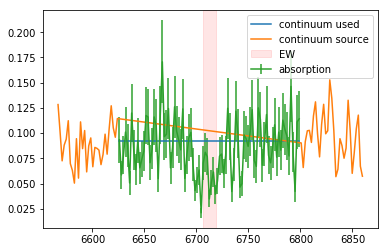

EW: 12.5981117341 +/- 4.39582624692


In [42]:
ew_robs1330=spt.get_generic_ew(rebin_j1330_obs, li_bounds, plot_all=True, cont_width=60, noise_method='rms')

So it's not insane that the EW value changed with the rebinning since the dlambda values were just estimated using the difference between successive centers of wavelength bins, which is most likely incorrect, to put it mildly. Also, this isn't really that different of a value as far as I'm concerned.

np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0233114263626 cont_noise_merge 0.00300949220262
abs_noise[1] 0.0231245734301
cont_spec.shape (2, 60)
abs_spec.shape (2, 89)
cont_energy 16.4357686881 +/- 0.0560069024688
abs_energy/abs_energy_noise: 36.0956109271
abs_energy 16.3038029946 +/- 0.451683807971
energy_dif 0.131965693484 +/- 0.45514287373


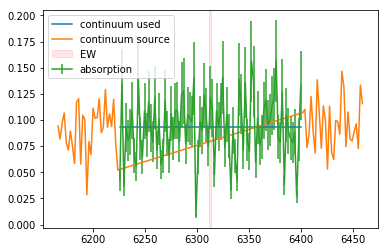

EW: 1.40965974896 +/- 4.86184380339


In [43]:
ew_robs1330=spt.get_generic_ew(rebin_j1330_obs, control_bounds, plot_all=True, cont_width=60, noise_method='rms')

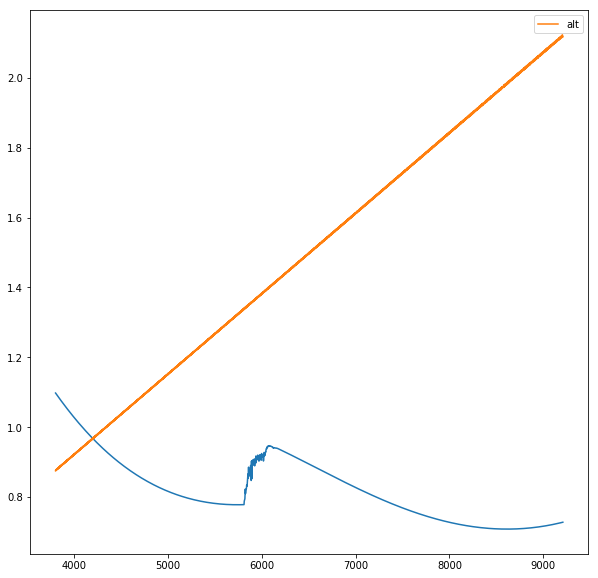

In [44]:
plt.figure(figsize=(10,10))
plt.plot(j1330_obs[0], j1330_obs_dlambda)
plt.plot(j1330_obs[0], j1330_obs_dlambda_alt, label='alt')
plt.legend()
plt.show()

Yeah, there's no way 'wdisp' is actually the dispersion at the wavelengths. Like that just doesn't seem to make any sense based on the differences in central wavelength values shown up there... unless they do some nonsense with the actual flux in each bin... oh god.

In [45]:
test_rebin= spt.rebin_generic_spec(j1330_obs, j1330_obs_dlambda, np.array([5000,6000,7000,8000]), np.array([1000, 1000,1000,1000]))

In [46]:
alt_test_rebin=spt.rebin_generic_spec(j1330_obs, j1330_obs_dlambda_alt, m0729_waves, m0729_dlambda)

In [47]:
inbounds=np.where((j1330_obs[0]>4500) & (j1330_obs[0]<5500))
summed_energy= np.sum(j1330_obs[1][inbounds]*j1330_obs_dlambda[inbounds])/1000.
print(summed_energy, test_rebin[1][0])

0.0655470980856 0.065557299681


So... that would appear to suggest that in actuality, the wdisp value is not in fact the header that describes the wavelength dispersion of the light, which one would normally use to produce the rebinned values, is either not actually the dispersion, or that it's incorrect for the rebinning? The damnedest part is that the approximated dlambda values using the difference of the central wavelength values was actually correct... Is it possible that the co-added version of the spectra actually aren't correctly combined in the SDSS pipeline? I mean one would normally assume that the method they use is probably correct, but... it does seem weird that I was able to "conserve" flux when I made sure the bins were approximately touching

### Anyway, I guess I should try the EW using a slightly smaller wavelength range to see if that's an improvement

np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.00362472045923 cont_noise_merge 0.000407812913292
abs_noise[1] 0.00314667227956
cont_spec.shape (2, 79)
abs_spec.shape (2, 77)
cont_energy 17.5703862222 +/- 0.00552943842777
abs_energy/abs_energy_noise: 355.469889741
abs_energy 15.2541697572 +/- 0.042912691616
energy_dif 2.31621646496 +/- 0.0432674680454


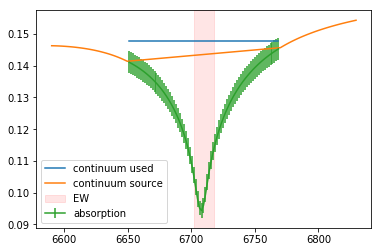

EW: 15.6840132397 +/- 0.292981054205
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0382653997463 cont_noise_merge 0.00436074701355
abs_noise[1] 0.0345791401686
cont_spec.shape (2, 77)
abs_spec.shape (2, 78)
cont_energy 20.1203713463 +/- 0.0595147806629
abs_energy/abs_energy_noise: 36.9224598397
abs_energy 18.1786086893 +/- 0.492345547079
energy_dif 1.94176265705 +/- 0.495929578515


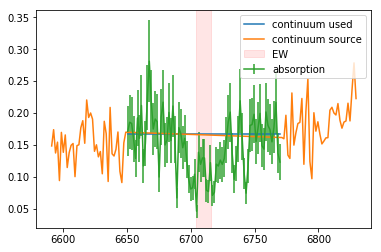

EW: 11.6322909407 +/- 2.97090744969


In [48]:
li_bounds= [6650,6770]
ew_m1330=spt.get_generic_ew(model1330, li_bounds, plot_all=True, cont_width=60, noise_method='rms')
ew_obs1330=spt.get_generic_ew(j1330_obs, li_bounds, plot_all=True, cont_width=60, noise_method='rms')

#### Well well well, that causes the SNR to actually approach the 3-sigma level now doesn't it.

np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0083722847726 cont_noise_merge 0.000918977642487
abs_noise[1] 0.00850050103069
cont_spec.shape (2, 83)
abs_spec.shape (2, 83)
cont_energy 15.6234756949 +/- 0.0121650235987
abs_energy/abs_energy_noise: 140.905494809
abs_energy 15.8649393757 +/- 0.112592765791
energy_dif -0.24146368084 +/- 0.113248040635


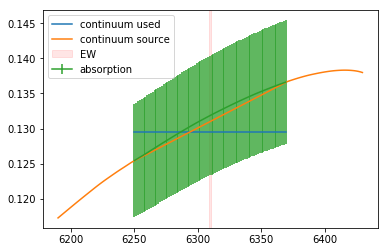

EW: -1.8638641971 +/- 0.874164460663
np.nanmean(noise_spec[1]) 1e-10
No dlams provided as a kwarg, so we'll make them up.
cont_noise_single 0.0502587362496 cont_noise_merge 0.00551661299245
abs_noise[1] 0.0519196184968
cont_spec.shape (2, 83)
abs_spec.shape (2, 82)
cont_energy 17.2044809746 +/- 0.0725939171529
abs_energy/abs_energy_noise: 24.9440057633
abs_energy 17.7755529186 +/- 0.71261821727
energy_dif -0.571071944007 +/- 0.716306219708


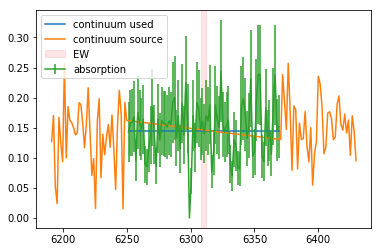

EW: -3.95527925242 +/- 4.961180739


In [49]:
control_bounds= [6250,6370]
ew_m1330=spt.get_generic_ew(model1330, control_bounds, plot_all=True, cont_width=60, noise_method='rms')
ew_obs1330=spt.get_generic_ew(j1330_obs, control_bounds, plot_all=True, cont_width=60, noise_method='rms')

Wait. Why would that smaller variation have actually caused the EW signal-to-noise to improve? The missing level of flux should not have changed at all... Like I'd suspect the insensitivity to wavelength range included would be a feature of this method of measuring absorption features...

Like I get that visually it appears to be a stronger case for being real if you limit the wavelength range further, but it doesn't really make any sense that the signal-to-noise would improve as a result since the continuum is what's used for those error bars, and that doesn't really change appreciably does it?

Like the first EW was 11.8 A and this one was 11.6, so those are the same as far as I'm concerned. What makes no sense at all is that the error bars then got smaller with a smaller absorption range included in the measurement.

Oh wait. It actually makes perfect sense that the error bar would get smaller with a smaller absorption range included in the measurement because I determine what the error bar on each absorption point should be using the rms in the continuum region. Then this error bar is applied to each point individually, so the more points that are included in the estimate the more error is included in the total "missing flux" summation, which means that implicitly, the uncertainty on the end result is actually the most certain if I only included one "absorption" point most likely... maybe I am incorrectly combining these uncertainties after all...

# I want to double check some stuff we're assuming about combining errors here...

In [50]:
sigma=1
loc=10
measurements=np.random.normal(loc=loc, scale=sigma, size=70)

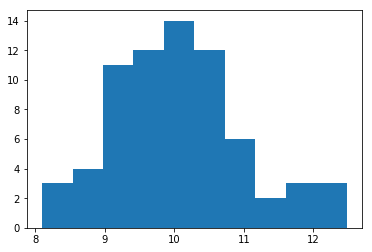

In [51]:
plt.hist(measurements)
plt.show()

In [52]:
np.std(measurements)

0.97033921553025482

In [53]:
np.sqrt(np.sum((measurements-np.mean(measurements))**2)/(measurements.shape[0]-1))

0.97734536583121556



wavelength-based norm range selected [6570, 6620]



1644model normed[6570, 6620]


wavelength-based norm range selected [6570, 6620]



1330model normed[6570, 6620]


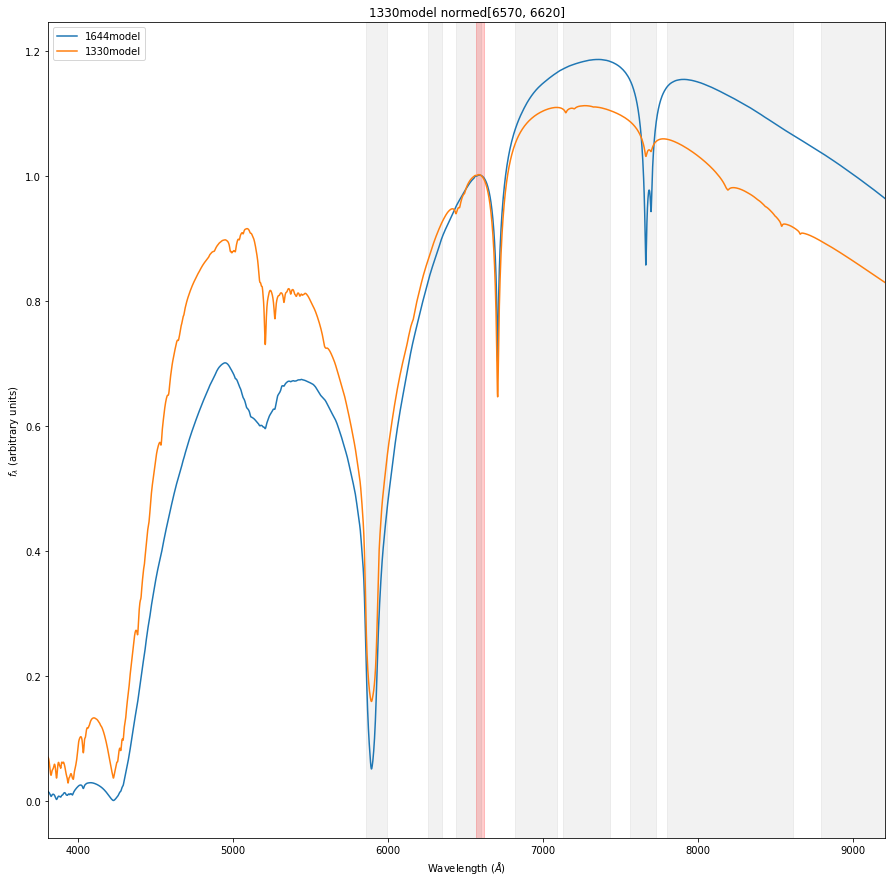

In [54]:
plt.figure(figsize=(15,15))
ps.plot_spectrum(model_spec, '1644model', '', norm=True)
ps.plot_spectrum(model1330, '1330model','',norm=True)
spt.show_plot()



wavelength-based norm range selected [6570, 6620]



J1644 2019-07-03 smoothed normed[6570, 6620]


wavelength-based norm range selected [6570, 6620]



J1330 smoothed normed[6570, 6620]


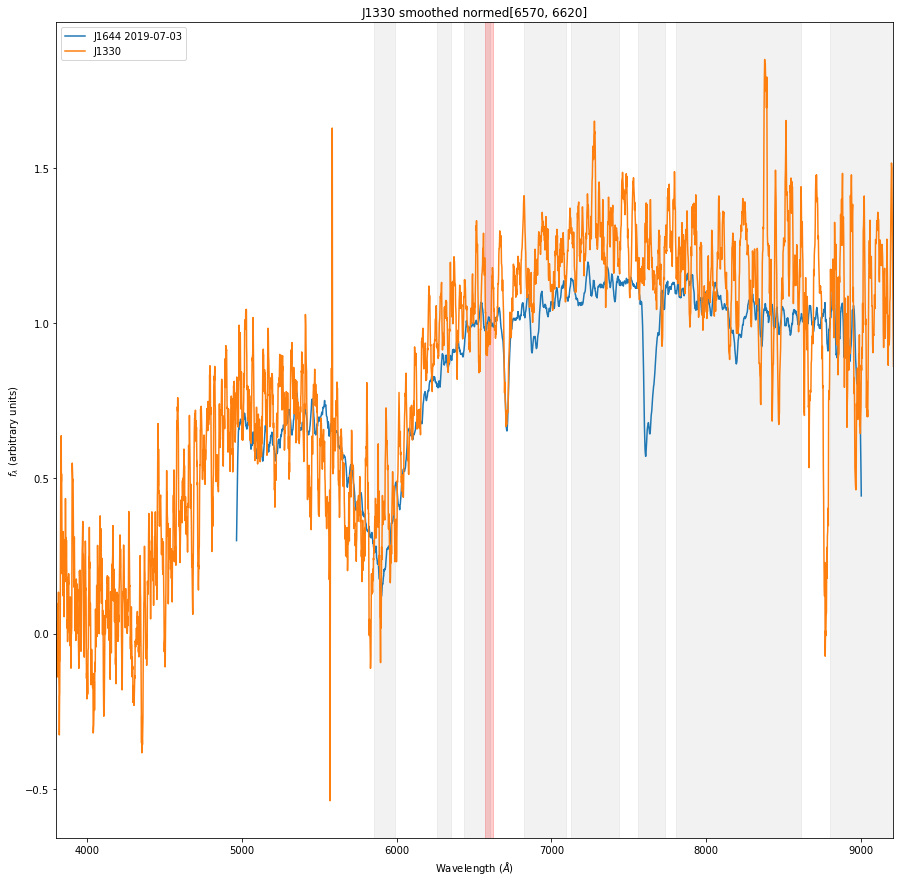

In [55]:
plt.figure(figsize=(15,15))
ps.plot_spectrum(M0703_spec, 'J1644 2019-07-03',M0703_header, smooth=True, norm=True)
ps.plot_spectrum(j1330_obs, 'J1330', '', smooth=True, norm=True, pix_width=10)
spt.show_plot()